In [158]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
#Importing all 3 files, grouping them to see each contributor's total contribution, and sorting them in descending order.
#Replace csv names with the names of your files. 
df1 = pd.read_csv('Susan M. Collins.csv')
df1 = df1.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)

df2 = pd.read_csv('Jim Risch.csv')
df2 = df2.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)

df3 = pd.read_csv('John Hoeven.csv')
df3 = df3.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)


In [160]:
df1.head(10)


,contributor_name,contribution_receipt_amount
904,WINRED,507522.71
192,COLLINS VICTORY COMMITTEE,286570.30
68,BANGOR SAVINGS BANK,75317.42
619,NO LABELS PROBLEM SOLVERS PAC,13000.00
248,DOCS PAC,10000.00
314,FUND FOR A CONSERVATIVE FUTURE,10000.00
316,"FURMAN, MATTHEW",10000.00
834,TRUE NORTH PAC,10000.00
168,"CHARTER COMMUNICATIONS, INC. PAC",10000.00
597,NATIONAL ASSOC OF BROADCASTERS PAC (NABPAC),10000.00


In [161]:
df2.head(10)


,contributor_name,contribution_receipt_amount
30,BANK OF IDAHO,60396.24
225,UBS AMERICAS INC. PAC (UBS PAC),10000.00
13,ALPHA SERVICES LLC,10000.00
217,THE PETER NORBECK LEADERSHIP PAC,10000.00
54,COMMON VALUES PAC,10000.00
223,TRUE NORTH PAC,10000.00
67,DEFEND OUR CONSERVATIVE SENATE PAC (DOC'S PAC),10000.00
18,AMERICAN EXCELLENCE PAC,10000.00
182,R SENATE PAC,10000.00
71,DIRIGO PAC,10000.00


In [162]:
df3.head(10)

,contributor_name,contribution_receipt_amount
1,2024 SENATORS CLASSIC COMMITTEE,52300.00
0,2023 SENATORS CLASSIC COMMITTEE,44430.00
286,WINRED,25212.15
75,CROP INSURANCE PROFESSIONALS ASSOCIATION PAC,10000.00
125,HESS CORPORATION POLITICAL ACTION COMMITTEE,10000.00
133,INTERNATIONAL UNION OF PAINTERS AND ALLIED TRA...,10000.00
190,NATIONAL RURAL WATER ASSOCIATION PAC,10000.00
226,REPUBLICAN MAJORITY FUND,10000.00
269,USAA EMPLOYEE PAC,7500.00
73,COVINGTON AND BURLING LLP PAC,7000.00


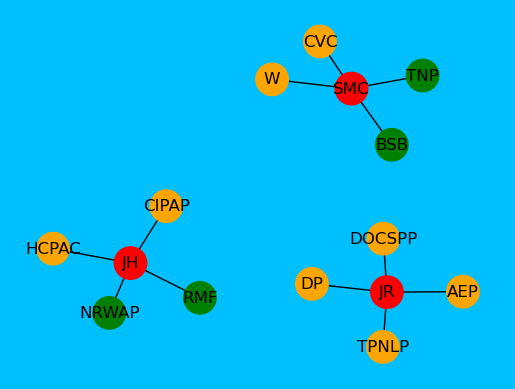

In [163]:
#This is where you place all of the information about the congress members! Include their names, and the funders/ donors that you chose (in their respected categories ofc)
#This is all you really need to change. IF you are working with Democrats, look for the other comment in the loop and change the color to "skyblue" (or whatever color you prefer ). 
members = [
    {
        "name": "Susan M. Collins",
        "fossil": ["WINRED", "COLLINS VICTORY COMMITTEE"],
        "green": ["TRUE NORTH PAC", "BANGOR SAVINGS BANK"]
    },
    {
        "name": "Jim Risch",
        "fossil": ["THE PETER NORBECK LEADERSHIP PAC", "DEFEND OUR CONSERVATIVE SENATE PAC (DOC'S PAC)", "AMERICAN EXCELLENCE PAC", "DIRIGO PAC"],
        "green": []
    },
    {
        "name": "John Hoeven",
        "fossil": ["CROP INSURANCE PROFESSIONALS ASSOCIATION PAC", "HESS CORPORATION POLITICAL ACTION COMMITTEE"],
        "green": ["NATIONAL RURAL WATER ASSOCIATION PAC", "REPUBLICAN MAJORITY FUND"]
    }
]

Gs = [nx.Graph(), nx.Graph(), nx.Graph()]

for i, (df, m) in enumerate(zip(dfs, members)):
    df["stance"] = "gray"
    df["target"] = m["name"]

    #Play around with these colors if you'd like, defaults are orange and green.
    df.loc[df["contributor_name"].isin(m["fossil"]), "stance"] = "orange"
    df.loc[df["contributor_name"].isin(m["green"]), "stance"] = "green"

    Gs[i] = nx.from_pandas_edgelist(df[df["contributor_name"].isin(m["fossil"] + m["green"])], source="contributor_name", target="target", edge_attr=["stance"])

    for _, row in df.iterrows():
        if row["contributor_name"] in Gs[i].nodes:
            Gs[i].nodes[row["contributor_name"]]["color"] = row["stance"]

    #If working with Democrats, change to "skyblue"
    Gs[i].nodes[m["name"]]["color"] = "red"

G1 = Gs[0]
G1.add_nodes_from(Gs[1].nodes(data=True))
G1.add_nodes_from(Gs[2].nodes(data=True))
G1.add_edges_from(Gs[1].edges(data=True))
G1.add_edges_from(Gs[2].edges(data=True))

key = []
labels = {}
for n in G1.nodes():
    parts = n.split() 
    letters = [p[0] for p in parts if p[0].isalpha()]
    labels[n] = "".join(letters)
    key.append({labels[n] : n})


node_colors = [G1.nodes[n].get("color", "gray") for n in G1.nodes()]

fig, ax = plt.subplots()
pos = nx.spring_layout(G1, k=1, iterations=100)
nx.draw(G1, pos=pos, with_labels=True, labels=labels, node_color=node_colors, node_size=500, edge_color='black', linewidths=2)
ax.axis('off')
#You can change the background color here. 
fig.set_facecolor('deepskyblue')
plt.show()

In [164]:
print("Key: ")
for item in key:
    for k, v in item.items( ):
        print(f"{k} = {v}") 


Key: 
W = WINRED
SMC = Susan M. Collins
CVC = COLLINS VICTORY COMMITTEE
BSB = BANGOR SAVINGS BANK
TNP = TRUE NORTH PAC
TPNLP = THE PETER NORBECK LEADERSHIP PAC
JR = Jim Risch
DOCSPP = DEFEND OUR CONSERVATIVE SENATE PAC (DOC'S PAC)
AEP = AMERICAN EXCELLENCE PAC
DP = DIRIGO PAC
CIPAP = CROP INSURANCE PROFESSIONALS ASSOCIATION PAC
JH = John Hoeven
HCPAC = HESS CORPORATION POLITICAL ACTION COMMITTEE
NRWAP = NATIONAL RURAL WATER ASSOCIATION PAC
RMF = REPUBLICAN MAJORITY FUND
